In [5]:
import numpy as np
import scipy as scipy
import matplotlib.pyplot as plt
from sympy import symbols, Eq, solve
from scipy.integrate import solve_ivp
import math

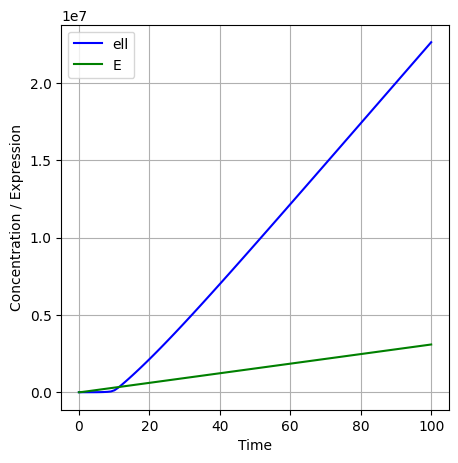

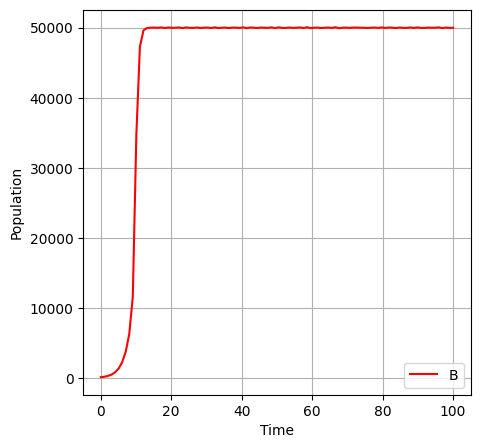

In [51]:
#parameter guessing for d and m based on: https://www.pnas.org/doi/pdf/10.1073/pnas.1319175111
p = 0.2
d = 0.045
m = 0.03
B = symbols('B')
l = symbols('l')
K =  5e4 #from paper; estimated based on model fit
r = 2 #estimated based on model fit; this a doubling time of 1hr
initial = 100
B_thresh = 1e4 #estimated population at threshold for logistic
k = math.log(B_thresh/initial)/9 #estimated to create a delay state
a = 1000 #initial gene expression
H = 0.875 # half the maximum signal concentration
c = 12.7e-6 #proportionality constant (in uM/RLU) for 3-oxo-C12-HSL; 25.4e-6 for C4-HSL
b = 30000 #maximum increase in expression
#parameters estimated from thomas_multi-signal_2023

def model(t, state):
    l, B, E = state
    dldt = c*E*B - d*l - m*l
    #dldt = 0
    if t<9: #9hrs estimated critical population from paper data
        dBdt = k*B #slow exponential growth at first; easier than delay function!
    else:
        dBdt = r*B*(1 - (B/K))
    E = a + b*(l/(l+H))
    return [dldt, dBdt, E]

t_span = (0, 100)
initial = (0.1, initial, 0)

t_evaluate = np.linspace(0, 100, 100)

sol = solve_ivp(fun = model, t_span = t_span, y0 = initial, method = 'RK45', t_eval = t_evaluate)

plt.figure(figsize=(5,5))
plt.plot(sol.t, sol.y[0], label='ell', color='blue')
#plt.plot(sol.t, sol.y[1], label='B', color='red')
plt.plot(sol.t, sol.y[2], label='E', color='green')
#plt.plot(sol.t, sol.y[3], label='R', color='orange')
plt.xlabel('Time')
plt.ylabel('Concentration / Expression')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(5,5))
#plt.plot(sol.t, sol.y[0], label='ell', color='blue')
plt.plot(sol.t, sol.y[1], label='B', color='red')
#plt.plot(sol.t, sol.y[2], label='E', color='green')
#plt.plot(sol.t, sol.y[3], label='R', color='orange')
plt.xlabel('Time')
plt.ylabel('Population')
plt.legend()
plt.grid(True)
plt.show()